In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv('data kotor\job_salary_prediction_dataset.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\j'
<>:1: SyntaxWarning: invalid escape sequence '\j'
C:\Users\HP\AppData\Local\Temp\ipykernel_16136\2069195154.py:1: SyntaxWarning: invalid escape sequence '\j'
  df = pd.read_csv('data kotor\job_salary_prediction_dataset.csv')


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [78]:
df.info(),df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


(None, (250000, 10))

In [79]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [80]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [81]:
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='salary'>

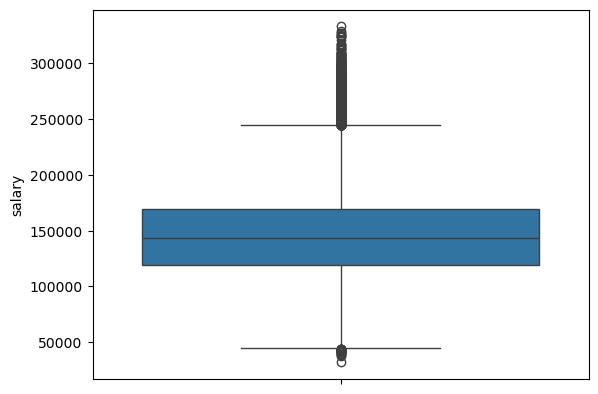

In [82]:
df_num = df.select_dtypes(include=[np.number])
sns.boxplot(df_num['salary'])

In [83]:
quartiles = df.select_dtypes(include=[np.number]).quantile([0, 0.25, 0.5, 0.75, 1.0])
quartiles.index = ["minimum","Q1","median","Q3","Maximum"]

print(quartiles)

         experience_years  skills_count  certifications    salary
minimum               0.0           1.0             0.0   31867.0
Q1                    5.0           5.0             1.0  119358.0
median               10.0          10.0             2.0  143453.0
Q3                   15.0          15.0             4.0  169492.0
Maximum              20.0          19.0             5.0  333046.0


In [84]:
IQR = quartiles.loc['Q3']-quartiles.loc['Q1']
lower_fence = quartiles.loc['Q3']-1.5*(IQR)
higher_fence = quartiles.loc['Q1']+1.5*(IQR)

print("\nIQR:",IQR)
print("\nbatas bawah: ",lower_fence)
print("\nbatas atas: ",higher_fence)


IQR: experience_years       10.0
skills_count           10.0
certifications          3.0
salary              50134.0
dtype: float64

batas bawah:  experience_years        0.0
skills_count            0.0
certifications         -0.5
salary              94291.0
dtype: float64

batas atas:  experience_years        20.0
skills_count            20.0
certifications           5.5
salary              194559.0
dtype: float64


In [85]:
df_num = df.select_dtypes(include=[np.number])
outliers_index = df[((df_num < lower_fence) | (df_num > higher_fence)).any(axis=1)].index
df = df.drop(outliers_index)


<Axes: >

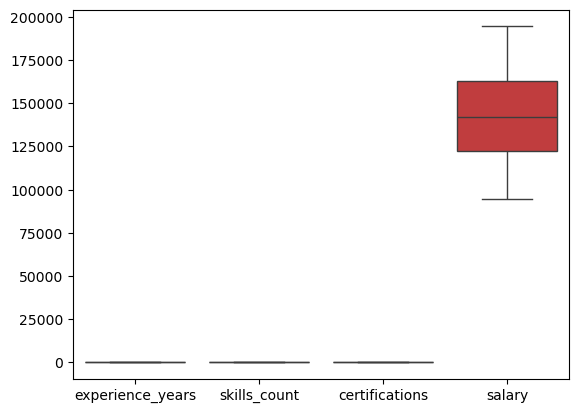

In [86]:
sns.boxplot(df)

In [87]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351


In [88]:
df_str = df.select_dtypes(include=['object'])
for col in df_str.columns:
    print(f"nilai unik kolom: {col}")
    print(df_str[col].unique())
    print("-"*70)

nilai unik kolom: job_title
['AI Engineer' 'Frontend Developer' 'Business Analyst' 'Product Manager'
 'Backend Developer' 'Machine Learning Engineer' 'DevOps Engineer'
 'Software Engineer' 'Cybersecurity Analyst' 'Data Scientist'
 'Cloud Engineer' 'Data Analyst']
----------------------------------------------------------------------
nilai unik kolom: education_level
['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']
----------------------------------------------------------------------
nilai unik kolom: industry
['Healthcare' 'Media' 'Retail' 'Manufacturing' 'Education' 'Telecom'
 'Finance' 'Consulting' 'Government' 'Technology']
----------------------------------------------------------------------
nilai unik kolom: company_size
['Medium' 'Large' 'Enterprise' 'Small' 'Startup']
----------------------------------------------------------------------
nilai unik kolom: location
['India' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands' 'Germany' 'UK'
 'Australia' 'Remote']
--------------

In [89]:
#label encoding (kategori setara/nominal)
df_nominal = df[['industry','location','remote_work']]

In [90]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
encoder = OneHotEncoder(sparse_output=False)

In [91]:
encoded = encoder.fit_transform(df[df_nominal.columns])
encoder_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(),index=df.index)
encoder_df.head(5)

,industry_Consulting,industry_Education,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [92]:
df = pd.concat([df,encoder_df],axis=1)


In [93]:
try:
    df= df.drop(columns=df_nominal.columns,axis=1)
except:
    print("Error: Kolom tidak ditemukan atau sudah dihapus.")
    df

In [94]:
df.head(5)

,job_title,experience_years,education_level,skills_count,company_size,certifications,salary,industry_Consulting,industry_Education,industry_Finance,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,AI Engineer,10,Bachelor,2,Medium,2,109413,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Frontend Developer,18,PhD,4,Medium,1,148123,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,19,PhD,13,Medium,0,189123,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,15,Bachelor,7,Large,0,165069,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,AI Engineer,0,High School,4,Enterprise,2,180351,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [95]:
# mengolah data oridnal
df_ordinal = df[['education_level','company_size']]
df_ordinal.head(5)


,education_level,company_size
0,Bachelor,Medium
2,PhD,Medium
3,PhD,Medium
4,Bachelor,Large
5,High School,Enterprise


In [96]:
encoder = OrdinalEncoder()

In [99]:
encoded = encoder.fit_transform(df[df_ordinal.columns])
df[df_ordinal.columns]= encoded
df.tail(5)

,job_title,experience_years,education_level,skills_count,company_size,certifications,salary,industry_Consulting,industry_Education,industry_Finance,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
249993,Frontend Developer,17,4.0,19,0.0,1,193028,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
249994,Business Analyst,13,1.0,17,1.0,3,171896,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
249995,Software Engineer,17,4.0,2,0.0,1,127791,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
249996,Frontend Developer,20,4.0,7,4.0,2,154593,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
249999,Data Analyst,16,1.0,2,2.0,5,133084,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [107]:
#normalisasi
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normal = df[['experience_years','skills_count','salary']]

In [110]:
normal = scaler.fit_transform(df[df_normal.columns])
df[df_normal.columns] = normal
df.head(5)

,job_title,experience_years,education_level,skills_count,company_size,certifications,salary,industry_Consulting,industry_Education,industry_Finance,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,AI Engineer,0.50,0.0,0.055556,2.0,2,0.150809,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,Frontend Developer,0.90,4.0,0.166667,2.0,1,0.536882,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,0.95,4.0,0.666667,2.0,0,0.945794,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,0.75,0.0,0.333333,1.0,0,0.705892,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
5,AI Engineer,0.00,2.0,0.166667,0.0,2,0.858307,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
#save data
# df.to_csv("data bersih/Job_Salary_Cleaning.csv",index=False)